# Modelling data - Version 10

This version includes all variables in the dataset **except for the solar generation variable "SOLAR".** **Range: 2024-01-01 to 2025-06-30**

<div>
Trabajo Integrador<br>
Maestría en Analítica e Inteligencia de Negocios<br>
Universidad del Valle<br>

</div>

#### Student
Camilo Andrés Jaramillo Tarapues - 2402218 

## Libraries

In [1]:
# Libraries

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.model_selection import GridSearchCV, cross_val_score, TimeSeriesSplit
import optuna
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from prophet import Prophet
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

# Metrics
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

## Dataset

In [2]:
# Cargar el conjunto de datos
df = pd.read_csv('../../data/out/dataset_final.csv')
df

,FECHA_HORA,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,...,FUEL_CONS_GAS,FUEL_CONS_GAS_NI,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
0,2020-01-01 00:00:00,2020,1,1,0,72.02,2109637.93,4418103.51,0.00,28880.74,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
1,2020-01-01 01:00:00,2020,1,1,1,136.71,1864989.80,4548853.97,0.00,29107.37,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
2,2020-01-01 02:00:00,2020,1,1,2,127.71,1720883.01,4525898.75,0.00,25939.87,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
3,2020-01-01 03:00:00,2020,1,1,3,127.71,1649014.61,4458645.56,0.00,25651.57,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
4,2020-01-01 04:00:00,2020,1,1,4,127.71,1711745.36,4279657.90,0.00,25245.37,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48187,2025-06-30 19:00:00,2025,6,30,19,112.55,1311491.62,9025510.46,2476.26,88117.23,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48188,2025-06-30 20:00:00,2025,6,30,20,112.55,1316147.03,8848494.08,1550.03,93431.69,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48189,2025-06-30 21:00:00,2025,6,30,21,106.25,1376475.95,8510792.32,0.00,95167.23,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48190,2025-06-30 22:00:00,2025,6,30,22,105.55,1401097.29,8058142.03,0.00,99156.29,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63


In [3]:
# Dropping column "SOLAR"

df = df.drop(columns=["SOLAR"])
df.head()

,FECHA_HORA,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,COGENERADOR,EOLICA,...,FUEL_CONS_GAS,FUEL_CONS_GAS_NI,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
0,2020-01-01 00:00:00,2020,1,1,0,72.02,2109637.93,4418103.51,28880.74,4291.34,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02
1,2020-01-01 01:00:00,2020,1,1,1,136.71,1864989.80,4548853.97,29107.37,3511.94,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02
2,2020-01-01 02:00:00,2020,1,1,2,127.71,1720883.01,4525898.75,25939.87,2641.90,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02
3,2020-01-01 03:00:00,2020,1,1,3,127.71,1649014.61,4458645.56,25651.57,3032.30,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02
4,2020-01-01 04:00:00,2020,1,1,4,127.71,1711745.36,4279657.90,25245.37,2514.76,...,167262.229,0.0,0.0,130.459523,240.075697,0.0,585.085344,0.42,-0.73,-0.02


### Filter dataset by data range: 2025-01-01 to 2025-06-30

In [4]:
df['FECHA_HORA'] = pd.to_datetime(df['FECHA_HORA'])

start_date = pd.to_datetime('2024-01-01')
end_date = pd.to_datetime('2025-06-30')

df = df[(df['FECHA_HORA'] >= start_date) & (df['FECHA_HORA'] <= end_date)]

In [5]:
print(f"DF size after filtering by date range:  {df.shape}")

DF size after filtering by date range:  (13105, 25)


In [6]:
print("Dataset info: ")
print(df.info())

Dataset info: 
<class 'pandas.core.frame.DataFrame'>
Index: 13105 entries, 35064 to 48168
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   FECHA_HORA             13105 non-null  datetime64[ns]
 1   YEAR                   13105 non-null  int64         
 2   MONTH                  13105 non-null  int64         
 3   DAY                    13105 non-null  int64         
 4   HORA                   13105 non-null  int64         
 5   PRECIO                 13105 non-null  float64       
 6   TERMICA                13105 non-null  float64       
 7   HIDRAULICA             13105 non-null  float64       
 8   COGENERADOR            13105 non-null  float64       
 9   EOLICA                 13105 non-null  float64       
 10  NIVEL_ENSO             13105 non-null  float64       
 11  FUEL_CONS_ACPM         13105 non-null  float64       
 12  FUEL_CONS_CARBON       13105 non-null  float64

In [7]:
print("Missing values by column:")
print(df.isnull().sum())

Missing values by column:
FECHA_HORA               0
YEAR                     0
MONTH                    0
DAY                      0
HORA                     0
PRECIO                   0
TERMICA                  0
HIDRAULICA               0
COGENERADOR              0
EOLICA                   0
NIVEL_ENSO               0
FUEL_CONS_ACPM           0
FUEL_CONS_CARBON         0
FUEL_CONS_COMBUSTOLEO    0
FUEL_CONS_CRUDO          0
FUEL_CONS_GAS            0
FUEL_CONS_GAS_NI         0
FUEL_CONS_GLP            0
FUEL_COST_CARBON         0
FUEL_COST_GAS            0
FUEL_COST_GAS_NI         0
FUEL_COST_COMBUSTOLEO    0
IPC_VAR_MOM_PCT          0
IPP_VAR_PN_MOM_PCT       0
IPP_VAR_OI_MOM_PCT       0
dtype: int64


**There are no missing values and all data is numeric, so it is ready to train the models.**

## Scale data

In [8]:
# Define target column 'PRECIO'
TARGET_COLUMN = 'PRECIO'

# Variables that are truly categorical even though they are numerical
categorical_numeric = ["YEAR", "MONTH", "DAY", "HORA", "NIVEL_ENSO"]

# Identify the continuous numerical columns that we do scale
numeric_features = [
    col for col in df.columns 
    if col not in categorical_numeric and col != TARGET_COLUMN and col != 'FECHA_HORA'
]

# Preprocessor: We only scale continuous numerics
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", "passthrough", categorical_numeric)
    ]
)

## Train, test and split data

Dividing the balanced dataset into two subsets: one to train the model8(70% of the data) and another to evaluate it (remainin2 30%

In [9]:
X = df.drop(columns=["FECHA_HORA", TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Split the dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mostrar el tamaño de cada conjunto
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (10484, 23)
Test set size: (2621, 23)


## Baseline Models

In [10]:
# Baseline models evaluation with multiple metrics

# Define dictionary of regression models
random_state=42

baseline_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_jobs=-1, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR(),  # may be slower on large datasets
    "KNN": KNeighborsRegressor(),  # may be slower on large datasets
}

# Define multiple metrics
scoring = {
    "r2": make_scorer(r2_score),
    "mae": make_scorer(mean_absolute_error),
    "mse": make_scorer(mean_squared_error),
    "rmse": make_scorer(lambda y, y_pred: root_mean_squared_error(y, y_pred))
}

In [11]:
results = {}

for name, model in baseline_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

results_df = pd.DataFrame(results).T
print(results_df)

                         r2         mae            mse        rmse
Linear Regression -1.041374  249.035766  146263.039873  339.807103
Ridge             -1.036212  248.860493  146152.885974  339.643656
Lasso             -0.995509  248.866057  141711.720502  336.971406
ElasticNet        -1.467314  276.238258  155846.359487  354.013483
Decision Tree     -2.520781  268.264209  187593.827571  401.864094
Random Forest     -1.960336  266.192487  175571.113128  378.405779
Gradient Boosting -1.484661  255.241682  148093.558306  350.695838
SVR               -4.967469  392.302707  267216.615014  458.415419
KNN               -1.983421  303.964573  201667.465742  407.712300


In [12]:
#                         r2         mae            mse        rmse
#Linear Regression -0.674345  176.143089   81073.484241  255.868922
#Ridge             -0.673436  176.120759   81060.409212  255.836226
#Lasso             -0.325634  165.753530   75625.847518  242.202735
#ElasticNet         0.185139  145.374287   62001.490904  211.163299
#Decision Tree     -3.449350  228.943037  184205.415683  378.558964
#Random Forest     -2.352729  192.978591  125518.982163  309.732879
#Gradient Boosting -0.639346  162.598554   89007.378341  248.218739
#SVR               -0.671078  232.611620  131116.991248  304.197465
#KNN               -0.225339  161.433940   77056.569938  242.010131

### GridSearch CV

In [13]:
# Define hiperparameters
param_grids = {
    "ElasticNet": {
        "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    "RandomForest": {
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10]
    },
    "GradientBoosting": {
        "model__n_estimators": [100, 200, 500],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 5, 7]
    }
}

# Define models
models = {
    "ElasticNet": ElasticNet(max_iter=10000, random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

In [14]:
# Para guardar resultados
best_models = {}
results = {}

for name, model in models.items():
    print("************************************************")
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    grid = GridSearchCV(
        pipe,
        param_grids[name],
        cv=5,
        scoring="r2",
        n_jobs=-1,
        verbose=1
    )
    
    grid.fit(X, y)
    
    best_models[name] = grid.best_estimator_
    results[name] = {
        "best_score": grid.best_score_,
        "best_params": grid.best_params_
    }
    print(f"Model: {name}")
    print(f"Best score: {grid.best_score_}")
    print(f"Best params: {grid.best_params_}")
    
results

************************************************
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Model: ElasticNet
Best score: -0.9207035314049505
Best params: {'model__alpha': 0.01, 'model__l1_ratio': 0.3}
************************************************
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Model: RandomForest
Best score: -1.461298144858762
Best params: {'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 300}
************************************************
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Model: GradientBoosting
Best score: -1.3488248485095735
Best params: {'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__n_estimators': 500}


{'ElasticNet': {'best_score': -0.9207035314049505,
  'best_params': {'model__alpha': 0.01, 'model__l1_ratio': 0.3}},
 'RandomForest': {'best_score': -1.461298144858762,
  'best_params': {'model__max_depth': 5,
   'model__min_samples_split': 2,
   'model__n_estimators': 300}},
 'GradientBoosting': {'best_score': -1.3488248485095735,
  'best_params': {'model__learning_rate': 0.01,
   'model__max_depth': 5,
   'model__n_estimators': 500}}}

In [15]:
#************************************************
#Fitting 5 folds for each of 30 candidates, totalling 150 fits
#Model: ElasticNet
#Best score: 0.2076746414849791
#Best params: {'model__alpha': 10, 'model__l1_ratio': 0.9}
#************************************************
#Fitting 5 folds for each of 36 candidates, totalling 180 fits
#Model: RandomForest
#Best score: -2.109574974486729
#Best params: {'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 300}
#************************************************
#Fitting 5 folds for each of 27 candidates, totalling 135 fits
#Model: GradientBoosting
#Best score: -0.46319237914950817
#Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 500}

### Boost models

In [16]:
robust_models = {
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0)
}

In [17]:
robust_results = {}

for name, model in robust_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    robust_results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

pd.DataFrame(robust_results).T

,r2,mae,mse,rmse
XGBoost,-2.040576,258.325387,160055.550254,363.810004
LightGBM,-1.562504,247.635859,158093.814406,358.995336
CatBoost,-1.334019,243.362918,148486.483233,340.328488


## Time Series Forecasting

### Splits the training and test sets as a time series

In [18]:
# Separar variables y target
X = df.drop(columns=["FECHA_HORA", TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Usar el índice para cortar: primeras 80% filas = train, últimas 20% filas = test
train_size = int(len(df) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (10484, 23)
Test set size: (2621, 23)


In [19]:
# Define temporal validation with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

results = {}

for name, model in baseline_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=tscv, scoring=scoring, n_jobs=-1)
    results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

results_df = pd.DataFrame(results).T
print(results_df)

                         r2         mae            mse        rmse
Linear Regression -3.559958  374.036433  227030.932715  452.065476
Ridge             -3.531819  373.998571  229605.050822  450.722966
Lasso             -3.252510  351.153216  223211.411125  428.709359
ElasticNet        -1.718455  311.500011  175550.884355  386.675086
Decision Tree     -0.797400  236.705439  146312.289942  330.491275
Random Forest     -0.528109  225.387430  134927.439364  310.100500
Gradient Boosting -1.306559  237.278143  130299.960318  320.715424
SVR               -5.250512  378.037128  248200.097421  443.337750
KNN               -0.734251  286.314728  181844.893203  369.462882


### Prophet

In [20]:
# Prepare data for Prophet: needs 'ds' (date) and 'y' (target)

df_prophet = df.copy()
df_prophet = df_prophet.drop(columns=["YEAR", "MONTH", "DAY", "HORA"])
df_prophet.head()

,FECHA_HORA,PRECIO,TERMICA,HIDRAULICA,COGENERADOR,EOLICA,NIVEL_ENSO,FUEL_CONS_ACPM,FUEL_CONS_CARBON,FUEL_CONS_COMBUSTOLEO,...,FUEL_CONS_GAS,FUEL_CONS_GAS_NI,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
35064,2024-01-01 00:00:00,251.91,1110705.18,6198917.64,16515.95,17292.56,3.0,339.0,123570.37016,670.54,...,80335.23,45395.3,0.0,173.021306,307.667402,623.127515,898.803038,0.92,0.59,0.81
35065,2024-01-01 01:00:00,251.91,1112836.70,6074385.60,16155.37,8292.50,3.0,339.0,123570.37016,670.54,...,80335.23,45395.3,0.0,173.021306,307.667402,623.127515,898.803038,0.92,0.59,0.81
35066,2024-01-01 02:00:00,251.91,1113080.66,5982315.72,16819.20,8737.69,3.0,339.0,123570.37016,670.54,...,80335.23,45395.3,0.0,173.021306,307.667402,623.127515,898.803038,0.92,0.59,0.81
35067,2024-01-01 03:00:00,281.91,1110708.24,5841597.74,16702.69,10862.55,3.0,339.0,123570.37016,670.54,...,80335.23,45395.3,0.0,173.021306,307.667402,623.127515,898.803038,0.92,0.59,0.81
35068,2024-01-01 04:00:00,281.91,899335.43,5949345.94,17741.16,8416.00,3.0,339.0,123570.37016,670.54,...,80335.23,45395.3,0.0,173.021306,307.667402,623.127515,898.803038,0.92,0.59,0.81


14:45:47 - cmdstanpy - INFO - Chain [1] start processing
14:45:50 - cmdstanpy - INFO - Chain [1] done processing


Prophet Forecasting Results:
MAE: 565.41, RMSE: 675.70, R2: -46.14


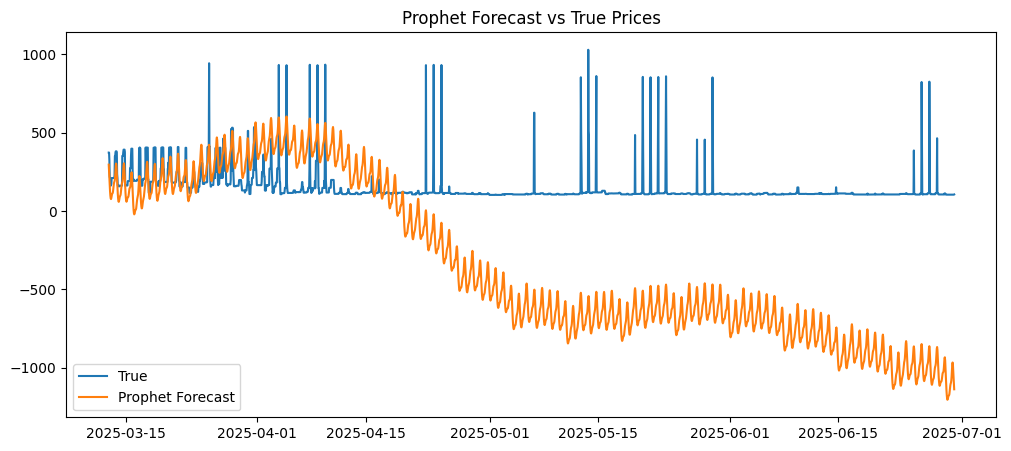

In [21]:
df_prophet = df_prophet.reset_index()[["FECHA_HORA", "PRECIO"]].rename(columns={"FECHA_HORA": "ds", "PRECIO": "y"})

# Train/test split: last 20% as test
train_size = int(len(df_prophet) * 0.8)
train_df, test_df = df_prophet.iloc[:train_size], df_prophet.iloc[train_size:]

# Fit Prophet model
prophet = Prophet(daily_seasonality=True, yearly_seasonality=True, weekly_seasonality=True)
prophet.fit(train_df)

# Forecast over test period
future = prophet.make_future_dataframe(periods=len(test_df), freq="h")
forecast = prophet.predict(future)

# Extract predictions only for test period
pred_prophet = forecast.set_index("ds").loc[test_df["ds"], "yhat"]

# Metrics
mae_p = mean_absolute_error(test_df["y"], pred_prophet)
rmse_p = root_mean_squared_error(test_df["y"], pred_prophet)
r2 = r2_score(test_df["y"], pred_prophet)

print("Prophet Forecasting Results:")
print(f"MAE: {mae_p:.2f}, RMSE: {rmse_p:.2f}, R2: {r2:.2f}")

# Plot forecast
plt.figure(figsize=(12, 5))
plt.plot(test_df["ds"], test_df["y"], label="True")
plt.plot(test_df["ds"], pred_prophet, label="Prophet Forecast")
plt.legend()
plt.title("Prophet Forecast vs True Prices")
plt.show()

### Ensemble Prophet + XGBoost

XGBoost with Prophet feature:
MAE: 99.09, RMSE: 132.81, R2: -0.82


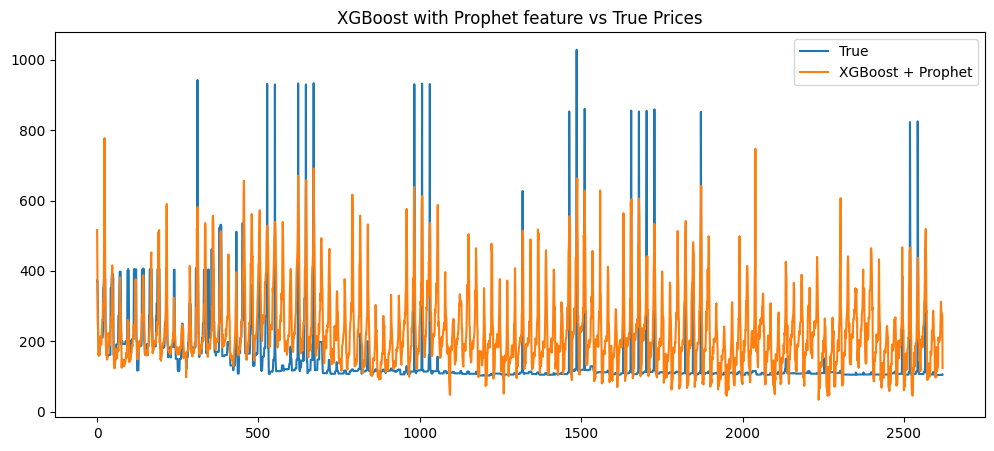

In [22]:
# --- Use Prophet as a feature for XGBoost ---

X_full = df.copy().drop(columns=["FECHA_HORA"])

# Add propehet prediction as a new column
X_full["prophet_yhat"] = forecast.set_index("ds")["yhat"].values

# Define train/test (temporal split)
X_train = X_full.iloc[:train_size].drop(columns=["PRECIO"])
y_train = X_full.iloc[:train_size]["PRECIO"]
X_test = X_full.iloc[train_size:].drop(columns=["PRECIO"])
y_test = X_full.iloc[train_size:]["PRECIO"]

# Train XGBoost
xgb_model = XGBRegressor(random_state=42, n_estimators=500, max_depth=6, learning_rate=0.1)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# --- Metrics ---
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = root_mean_squared_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost with Prophet feature:")
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

# --- Paso 5: Graficamos ---
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="True")
plt.plot(y_pred_xgb, label="XGBoost + Prophet")
plt.legend()
plt.title("XGBoost with Prophet feature vs True Prices")
plt.show()

## Train and test with lags

In [23]:
# --- Create lag features ---
def create_lags(df, target_col, n_lags=24):
    df_lagged = df.copy()
    for lag in range(1, n_lags+1):
        df_lagged[f"{target_col}_lag{lag}"] = df_lagged[target_col].shift(lag)
    return df_lagged.dropna()

df_lagged = create_lags(df, target_col="PRECIO", n_lags=24)
df_lagged = df_lagged.dropna()

# Features (all except date & target)
X = df_lagged.drop(columns=["FECHA_HORA", "PRECIO"])
y = df_lagged["PRECIO"]

# --- Train/Test split ---
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

In [24]:
X_train.head()

,YEAR,MONTH,DAY,HORA,TERMICA,HIDRAULICA,COGENERADOR,EOLICA,NIVEL_ENSO,FUEL_CONS_ACPM,...,PRECIO_lag15,PRECIO_lag16,PRECIO_lag17,PRECIO_lag18,PRECIO_lag19,PRECIO_lag20,PRECIO_lag21,PRECIO_lag22,PRECIO_lag23,PRECIO_lag24
35088,2024,1,2,0,1285160.40,6061958.38,13510.68,10965.50,3.0,293.86,...,95.85,95.85,95.85,152.91,251.91,281.91,281.91,251.91,251.91,251.91
35089,2024,1,2,1,1252557.85,5863196.52,12693.41,11778.13,3.0,293.86,...,95.85,95.85,95.85,95.85,152.91,251.91,281.91,281.91,251.91,251.91
35090,2024,1,2,2,1210894.06,5740740.85,13030.87,12646.47,3.0,293.86,...,152.91,95.85,95.85,95.85,95.85,152.91,251.91,281.91,281.91,251.91
35091,2024,1,2,3,1209337.44,5667752.92,13230.69,11186.29,3.0,293.86,...,152.91,152.91,95.85,95.85,95.85,95.85,152.91,251.91,281.91,281.91
35092,2024,1,2,4,1032092.14,5902949.98,13449.09,11501.69,3.0,293.86,...,152.91,152.91,152.91,95.85,95.85,95.85,95.85,152.91,251.91,281.91


### XGBoost Forecasting with Lags

XGBoost Forecasting Results:
MAE: 42.99, RMSE: 78.48, R2: 0.36


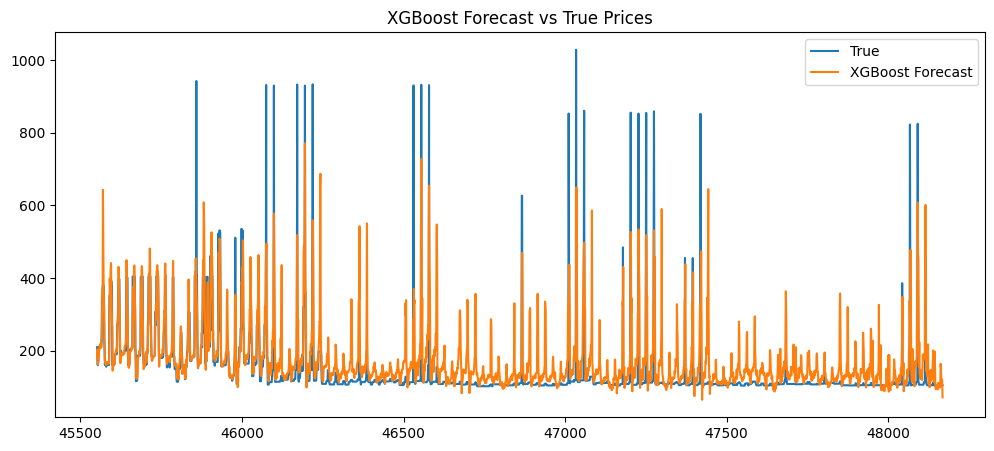

In [25]:
# ===========================================
# XGBoost Forecasting with Lags
# ===========================================

# Train XGBoost
model_xgb = XGBRegressor(objective="reg:squarederror", n_estimators=200, learning_rate=0.1, max_depth=6)
model_xgb.fit(X_train, y_train)

# Predictions
pred_xgb = model_xgb.predict(X_test)

# Metrics
mae_x = mean_absolute_error(y_test, pred_xgb)
rmse_x = root_mean_squared_error(y_test, pred_xgb)
r2_x = r2_score(y_test, pred_xgb)

print("XGBoost Forecasting Results:")
print(f"MAE: {mae_x:.2f}, RMSE: {rmse_x:.2f}, R2: {r2_x:.2f}")

# Plot forecast
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label="True")
plt.plot(y_test.index, pred_xgb, label="XGBoost Forecast")
plt.legend()
plt.title("XGBoost Forecast vs True Prices")
plt.show()

### Boosting with lags

In [26]:
models = {
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=-1, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_state=42, verbose=0)
}

In [27]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

df_results = pd.DataFrame(results).T
print(df_results)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003727 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9508
[LightGBM] [Info] Number of data points in the train set: 10464, number of used features: 46
[LightGBM] [Info] Start training from score 637.692526
                MAE       RMSE        R2
XGBoost   62.716761  93.110782  0.101293
LightGBM  59.074796  83.001049  0.285857
CatBoost  43.243413  74.725614  0.421162


### Boosting with lags (tunning)

In [28]:
# ===================== OBJECTIVES =====================

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5)
    }

    model = XGBRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE


def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0)
    }

    model = LGBMRegressor(**params, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE


def objective_cat(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 3, 12),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1)
    }

    model = CatBoostRegressor(**params, random_state=42, verbose=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE

In [29]:
# ===================== RUN STUDIES =====================

studies = {}
for name, objective in [("XGBoost", objective_xgb), 
                        ("LightGBM", objective_lgbm), 
                        ("CatBoost", objective_cat)]:
    print(f"Running Optuna for {name}...")
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=100)  # puedes subir n_trials si quieres
    studies[name] = study
    print(f"Best params for {name}: {study.best_trial.params}")
    print(f"Best RMSE: {study.best_value:.4f}\n")


# ===================== FINAL EVALUATION =====================

results = {}
best_params = {}
best_scores = {}

for name, study in studies.items():
    if name == "XGBoost":
        model = XGBRegressor(**study.best_trial.params, random_state=42, n_jobs=-1)
    elif name == "LightGBM":
        model = LGBMRegressor(**study.best_trial.params, random_state=42)
    else:
        model = CatBoostRegressor(**study.best_trial.params, random_state=42, verbose=0)

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    best_params[name] = study.best_trial.params
    best_scores[name] = study.best_value
    
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": root_mean_squared_error(y_test, preds),
        "R2": r2_score(y_test, preds)
    }


[I 2025-09-03 14:46:12,893] A new study created in memory with name: no-name-ecf2cdbc-c35b-4069-9c6d-97c6d59b63a9


Running Optuna for XGBoost...


[I 2025-09-03 14:46:26,257] Trial 0 finished with value: 101.18568307654527 and parameters: {'n_estimators': 678, 'learning_rate': 0.08230294463396923, 'max_depth': 10, 'subsample': 0.6999217292527969, 'colsample_bytree': 0.706727218113475, 'gamma': 2.9741457192752403, 'reg_alpha': 2.6080738150773546, 'reg_lambda': 1.4776952588123249}. Best is trial 0 with value: 101.18568307654527.
[I 2025-09-03 14:46:32,897] Trial 1 finished with value: 79.16424163554285 and parameters: {'n_estimators': 791, 'learning_rate': 0.06960220372705969, 'max_depth': 7, 'subsample': 0.9422584498939243, 'colsample_bytree': 0.6306634106294583, 'gamma': 3.827291400647037, 'reg_alpha': 0.3033106864159407, 'reg_lambda': 2.355288098150821}. Best is trial 1 with value: 79.16424163554285.
[I 2025-09-03 14:46:40,626] Trial 2 finished with value: 106.79221652438547 and parameters: {'n_estimators': 1109, 'learning_rate': 0.04743775144521791, 'max_depth': 6, 'subsample': 0.643780219864802, 'colsample_bytree': 0.996464820

Best params for XGBoost: {'n_estimators': 882, 'learning_rate': 0.011048561614185614, 'max_depth': 4, 'subsample': 0.9926819265134854, 'colsample_bytree': 0.9349769208295758, 'gamma': 0.25184648763774886, 'reg_alpha': 4.262657945638939, 'reg_lambda': 4.197500845631953}
Best RMSE: 65.9883

Running Optuna for LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004689 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9508
[LightGBM] [Info] Number of data points in the train set: 10464, number of used features: 46
[LightGBM] [Info] Start training from score 637.692526
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

[I 2025-09-03 14:56:07,977] Trial 0 finished with value: 101.60326305284438 and parameters: {'n_estimators': 1151, 'learning_rate': 0.12684810399400565, 'num_leaves': 104, 'max_depth': 7, 'min_child_samples': 42, 'subsample': 0.8701041314428529, 'colsample_bytree': 0.7276545737612646}. Best is trial 0 with value: 101.60326305284438.


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003065 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9508
[LightGBM] [Info] Number of data points in the train set: 10464, number of used features: 46
[LightGBM] [Info] Start training from score 637.692526
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

[I 2025-09-03 15:03:53,417] Trial 99 finished with value: 70.64634823377459 and parameters: {'n_estimators': 677, 'learning_rate': 0.020856743400455357, 'num_leaves': 103, 'max_depth': 6, 'min_child_samples': 39, 'subsample': 0.6981327131092995, 'colsample_bytree': 0.6833495244027207}. Best is trial 84 with value: 66.01156928606072.
[I 2025-09-03 15:03:53,432] A new study created in memory with name: no-name-e69fb4c0-4808-4e1a-ac92-4d29d7022d10


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Best params for LightGBM:

[I 2025-09-03 15:04:01,871] Trial 0 finished with value: 109.93718820888704 and parameters: {'iterations': 1024, 'learning_rate': 0.14534835464364465, 'depth': 5, 'l2_leaf_reg': 1.5462514916329817, 'bagging_temperature': 0.6558055660850449}. Best is trial 0 with value: 109.93718820888704.
[I 2025-09-03 15:04:05,932] Trial 1 finished with value: 71.71779112681757 and parameters: {'iterations': 661, 'learning_rate': 0.06764669980435403, 'depth': 4, 'l2_leaf_reg': 9.326202281539883, 'bagging_temperature': 0.7533553859721556}. Best is trial 1 with value: 71.71779112681757.
[I 2025-09-03 15:04:31,253] Trial 2 finished with value: 97.606566743996 and parameters: {'iterations': 1482, 'learning_rate': 0.22072265997406884, 'depth': 7, 'l2_leaf_reg': 7.854469218847447, 'bagging_temperature': 0.6706193225314945}. Best is trial 1 with value: 71.71779112681757.
[I 2025-09-03 15:07:04,777] Trial 3 finished with value: 97.6979098720539 and parameters: {'iterations': 1295, 'learning_rate': 0.135907412

Best params for CatBoost: {'iterations': 777, 'learning_rate': 0.03522164041056337, 'depth': 6, 'l2_leaf_reg': 4.531202067816096, 'bagging_temperature': 0.7198976868910305}
Best RMSE: 68.8131

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003137 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9508
[LightGBM] [Info] Number of data points in the train set: 10464, number of used features: 46
[LightGBM] [Info] Start training from score 637.692526
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [W

In [30]:
params_df = pd.DataFrame(best_params).T
params_df["Best_RMSE"] = pd.Series(best_scores)
results_df = pd.DataFrame(results).T

print("\n===== Best Hyperparameters per Model =====")
print(params_df)
print(results_df)


===== Best Hyperparameters per Model =====
          n_estimators  learning_rate  max_depth  subsample  colsample_bytree  \
XGBoost          882.0       0.011049        4.0   0.992682          0.934977   
LightGBM         633.0       0.015903        6.0   0.668371          0.671666   
CatBoost           NaN       0.035222        NaN        NaN               NaN   

             gamma  reg_alpha  reg_lambda  num_leaves  min_child_samples  \
XGBoost   0.251846   4.262658    4.197501         NaN                NaN   
LightGBM       NaN        NaN         NaN        91.0               16.0   
CatBoost       NaN        NaN         NaN         NaN                NaN   

          iterations  depth  l2_leaf_reg  bagging_temperature  Best_RMSE  
XGBoost          NaN    NaN          NaN                  NaN  65.988285  
LightGBM         NaN    NaN          NaN                  NaN  66.011569  
CatBoost       777.0    6.0     4.531202             0.719898  68.813064  
                MAE       

### Baseline models with lag

In [31]:
# Entrenar cada modelo base con cross-validation
results_base = {}

# Define temporal validation with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

for name, model in baseline_models.items():
    scores = cross_validate(model, X, y, cv=tscv, scoring=scoring, n_jobs=-1)
    results_base[name] = {
        metric: np.mean(scores[f"test_{metric}"]) for metric in scoring.keys()
    }

# Mostrar resultados
results_base_df = pd.DataFrame(results_base).T
print(results_base_df)

                         r2         mae            mse        rmse
Linear Regression  0.714012   67.522020   14817.989928  111.695820
Ridge              0.715258   66.547372   14749.354417  111.255516
Lasso              0.752580   48.251783   12692.884672   99.013403
ElasticNet         0.755590   46.718552   12558.723011   98.153060
Decision Tree      0.277813  151.181174   95063.734162  239.719495
Random Forest      0.603560  106.978926   49797.521977  173.389849
Gradient Boosting  0.707615   91.401932   44058.500672  160.291728
SVR               -0.792524  286.275576  180732.657858  353.147519
KNN               -0.146025  217.373020  138927.962538  297.406780


### Baseline models (linear) with lag (tunning)

In [32]:
# ========================
# Setting
# ========================

# Split
tscv = TimeSeriesSplit(n_splits=5)

# Scorers
scoring = {
    "r2": make_scorer(r2_score),
    "mae": make_scorer(mean_absolute_error),
    "rmse": make_scorer(lambda y, y_pred: root_mean_squared_error(y, y_pred))
}

# ========================
# Linear models → GridSearchCV
# ========================

linear_grids = {
    "Linear Regression": (LinearRegression(), {}),
    "Ridge": (Ridge(), {"alpha": [0.01, 0.1, 1, 10, 100]}),
    "Lasso": (Lasso(max_iter=5000), {"alpha": [0.001, 0.01, 0.1, 1, 10]}),
    "ElasticNet": (ElasticNet(max_iter=5000), {
        "alpha": [0.001, 0.01, 0.1, 1, 10],
        "l1_ratio": [0.1, 0.5, 0.9]
    }),
}

In [33]:
results = {}

for name, (model, grid) in linear_grids.items():
    search = GridSearchCV(
        model,
        param_grid=grid,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        n_jobs=-1
    )
    search.fit(X, y)
    best_model = search.best_estimator_

    # Cross-validate with multiple metrics
    scores = cross_val_score(best_model, X, y, cv=tscv, scoring="r2")
    r2 = scores.mean()
    scores_mae = cross_val_score(best_model, X, y, cv=tscv, scoring="neg_mean_absolute_error")
    mae = -scores_mae.mean()
    scores_rmse = cross_val_score(best_model, X, y, cv=tscv, scoring="neg_root_mean_squared_error")
    rmse = -scores_rmse.mean()

    results[name] = {
        "Best Params": search.best_params_,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }

df_results = pd.DataFrame(results).T
df_results

,Best Params,R2,MAE,RMSE
Linear Regression,{},0.714012,67.52202,111.69582
Ridge,{'alpha': 100},0.731772,58.462431,105.753773
Lasso,{'alpha': 10},0.758164,45.347211,97.422263
ElasticNet,"{'alpha': 10, 'l1_ratio': 0.9}",0.758133,45.388492,97.445844


In [34]:
#Best Params	R2	MAE	RMSE
#Linear Regression	{}	0.948861	26.688284	55.639576
#Ridge	{'alpha': 100}	0.949168	26.595779	55.589767
#Lasso	{'alpha': 0.1}	0.949673	26.3468	55.473241
#ElasticNet	{'alpha': 0.1, 'l1_ratio': 0.9}	0.949626	26.345297	55.47959

### Baseline models (non-linear) with lag (tunning)

In [35]:
# ========================
# Non-linear models → Optuna
# ========================

# Split
tscv = TimeSeriesSplit(n_splits=5)

def optuna_objective(trial, model_name):
    
    if model_name == "Decision Tree":
        model = DecisionTreeRegressor(
            max_depth=trial.suggest_int("max_depth", 2, 20),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            random_state=42
        )

    elif model_name == "Random Forest":
        model = RandomForestRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 1000),
            max_depth=trial.suggest_int("max_depth", 2, 20),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            n_jobs=-1, random_state=42
        )

    elif model_name == "Gradient Boosting":
        model = GradientBoostingRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 1000),
            learning_rate=trial.suggest_float("learning_rate", 0.001, 0.2, log=True),
            max_depth=trial.suggest_int("max_depth", 2, 10),
            subsample=trial.suggest_float("subsample", 0.5, 1.0),
            random_state=42
        )

    # CV RMSE
    scores = cross_val_score(model, X, y, cv=tscv, scoring="neg_root_mean_squared_error")
    return -scores.mean()

In [36]:
nonlinear_models = ["Decision Tree", "Random Forest", "Gradient Boosting"]

In [37]:
nonlinear_results = {}

for name in nonlinear_models:
    study = optuna.create_study(direction="minimize")
    study.optimize(lambda trial: optuna_objective(trial, name), n_trials=30, n_jobs=-1)

    best_params = study.best_params

    # Entrenar con los mejores parámetros
    if name == "Decision Tree":
        best_model = DecisionTreeRegressor(**best_params, random_state=42)
    elif name == "Random Forest":
        best_model = RandomForestRegressor(**best_params, n_jobs=-1, random_state=42)
    elif name == "Gradient Boosting":
        best_model = GradientBoostingRegressor(**best_params, random_state=42)

    # Cross-validate with metrics
    r2 = cross_val_score(best_model, X, y, cv=tscv, scoring="r2").mean()
    mae = -cross_val_score(best_model, X, y, cv=tscv, scoring="neg_mean_absolute_error").mean()
    rmse = -cross_val_score(best_model, X, y, cv=tscv, scoring="neg_root_mean_squared_error").mean()

    nonlinear_results[name] = {
        "Best Params": best_params,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }

df_nonlinear_results = pd.DataFrame(nonlinear_results).T
df_nonlinear_results

[I 2025-09-03 15:47:09,798] A new study created in memory with name: no-name-5e60868c-2fcc-4a09-b74b-d6c73e5dc4a4
[I 2025-09-03 15:47:11,415] Trial 18 finished with value: 269.24182060963744 and parameters: {'max_depth': 2, 'min_samples_split': 2}. Best is trial 18 with value: 269.24182060963744.
[I 2025-09-03 15:47:12,037] Trial 7 finished with value: 226.1448042317374 and parameters: {'max_depth': 4, 'min_samples_split': 16}. Best is trial 7 with value: 226.1448042317374.
[I 2025-09-03 15:47:12,388] Trial 19 finished with value: 226.1448042317374 and parameters: {'max_depth': 4, 'min_samples_split': 14}. Best is trial 7 with value: 226.1448042317374.
[I 2025-09-03 15:47:12,786] Trial 14 finished with value: 217.68675812565397 and parameters: {'max_depth': 5, 'min_samples_split': 14}. Best is trial 14 with value: 217.68675812565397.
[I 2025-09-03 15:47:13,597] Trial 20 finished with value: 226.1448042317374 and parameters: {'max_depth': 4, 'min_samples_split': 10}. Best is trial 14 wi

,Best Params,R2,MAE,RMSE
Decision Tree,"{'max_depth': 5, 'min_samples_split': 14}",0.369736,130.535884,217.686758
Random Forest,"{'n_estimators': 147, 'max_depth': 14, 'min_sa...",0.683061,95.684159,148.150947
Gradient Boosting,"{'n_estimators': 929, 'learning_rate': 0.00768...",0.691834,90.945054,150.564455


In [38]:
nonlinear_results

{'Decision Tree': {'Best Params': {'max_depth': 5, 'min_samples_split': 14},
  'R2': 0.3697358061898398,
  'MAE': 130.53588417490278,
  'RMSE': 217.68675812565397},
 'Random Forest': {'Best Params': {'n_estimators': 147,
   'max_depth': 14,
   'min_samples_split': 6,
   'max_features': 'sqrt'},
  'R2': 0.6830614619365836,
  'MAE': 95.68415948948555,
  'RMSE': 148.1509465614656},
 'Gradient Boosting': {'Best Params': {'n_estimators': 929,
   'learning_rate': 0.007683429052456394,
   'max_depth': 2,
   'subsample': 0.7641899717067021},
  'R2': 0.6918336743934672,
  'MAE': 90.94505422842538,
  'RMSE': 150.564454955175}}

In [39]:
#Best Params	R2	MAE	RMSE
#Linear Regression	{}	0.948861	26.688284	55.639576
#Ridge	{'alpha': 100}	0.949168	26.595779	55.589767
#Lasso	{'alpha': 0.1}	0.949673	26.3468	55.473241
#ElasticNet	{'alpha': 0.1, 'l1_ratio': 0.9}	0.949626	26.345297	55.47959
#Decision Tree	{'max_depth': 5, 'min_samples_split': 8}	0.852894	47.07064	98.828144
#Random Forest	{'n_estimators': 380, 'max_depth': 5, 'min_samples_split': 7,'max_features': None}	0.875931	44.651063	97.202218

In [40]:
# Random forest
#{'Best Params': {'n_estimators': 380,
#  'max_depth': 5,
#  'min_samples_split': 7,
#  'max_features': None},
# 'R2': 0.8759310854350622,
# 'MAE': 44.6510629713005,
# 'RMSE': 97.20221800266624}

In [41]:
#{'Decision Tree': {'Best Params': {'max_depth': 5, 'min_samples_split': 17},
#  'R2': 0.8528940981487452,
#  'MAE': 47.07063996534437,
#  'RMSE': 98.82814400209875},
# 'Random Forest': {'Best Params': {'n_estimators': 407,
#   'max_depth': 4,
#   'min_samples_split': 16,
#   'max_features': None},
#  'R2': 0.8626976844486611,
#  'MAE': 47.776218604543374,
#  'RMSE': 101.92848807043003},
# 'Gradient Boosting': {'Best Params': {'n_estimators': 710,
#   'learning_rate': 0.004824184299163144,
#   'max_depth': 2,
#   'subsample': 0.54752888994856},
#  'R2': 0.8518062305030419,
#  'MAE': 50.53916588389959,
#  'RMSE': 103.0669818471433}}

results 0 with value: 98.0681054649906.

### Other robust models

In [42]:
# Nuevos modelos robustos
new_models = {
    "Extra Trees": ExtraTreesRegressor(n_jobs=-1, random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=42),
    "MLP Regressor": MLPRegressor(random_state=42, max_iter=500)
}

In [43]:
# Evaluación
results_new = {}

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "rmse": "neg_root_mean_squared_error"
}

for name, model in new_models.items():
    pipe = Pipeline(steps=[("model", model)])
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    results_new[name] = {metric: abs(scores[f"test_{metric}"].mean()) if metric != "r2"
                         else scores[f"test_{metric}"].mean()
                         for metric in scoring.keys()}

df_results_new = pd.DataFrame(results_new).T
print(df_results_new)

                                r2          mae           mse         rmse
Extra Trees               0.669441    85.513732  4.457805e+04   147.866998
Hist Gradient Boosting    0.711435    79.342577  4.335713e+04   143.979288
MLP Regressor          -368.397842  1826.047350  6.097001e+06  2175.374704


<hr>

## Long short-term memory (LSTM)

In [44]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [45]:
# Numerical variables
print(numeric_features)

['TERMICA', 'HIDRAULICA', 'COGENERADOR', 'EOLICA', 'FUEL_CONS_ACPM', 'FUEL_CONS_CARBON', 'FUEL_CONS_COMBUSTOLEO', 'FUEL_CONS_CRUDO', 'FUEL_CONS_GAS', 'FUEL_CONS_GAS_NI', 'FUEL_CONS_GLP', 'FUEL_COST_CARBON', 'FUEL_COST_GAS', 'FUEL_COST_GAS_NI', 'FUEL_COST_COMBUSTOLEO', 'IPC_VAR_MOM_PCT', 'IPP_VAR_PN_MOM_PCT', 'IPP_VAR_OI_MOM_PCT']


In [46]:
# Scale numerical variables

# ============================
# 1. Prepare data
# ============================

scaler = MinMaxScaler()
df_scaled = df.copy().drop(columns=["FECHA_HORA"])
df_scaled[numeric_features] = scaler.fit_transform(df[numeric_features])
df_scaled

,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,COGENERADOR,EOLICA,NIVEL_ENSO,...,FUEL_CONS_GAS,FUEL_CONS_GAS_NI,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
35064,2024,1,1,0,251.91,0.138481,0.493743,0.106362,0.541970,3.0,...,0.234421,0.113755,0.0,0.985882,0.042734,0.216801,0.555834,0.826772,0.621818,0.791111
35065,2024,1,1,1,251.91,0.138947,0.478087,0.103921,0.259897,3.0,...,0.234421,0.113755,0.0,0.985882,0.042734,0.216801,0.555834,0.826772,0.621818,0.791111
35066,2024,1,1,2,251.91,0.139001,0.466512,0.108416,0.273850,3.0,...,0.234421,0.113755,0.0,0.985882,0.042734,0.216801,0.555834,0.826772,0.621818,0.791111
35067,2024,1,1,3,281.91,0.138481,0.448821,0.107627,0.340445,3.0,...,0.234421,0.113755,0.0,0.985882,0.042734,0.216801,0.555834,0.826772,0.621818,0.791111
35068,2024,1,1,4,281.91,0.092202,0.462367,0.114658,0.263768,3.0,...,0.234421,0.113755,0.0,0.985882,0.042734,0.216801,0.555834,0.826772,0.621818,0.791111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48164,2025,6,29,20,104.95,0.161700,0.779412,0.692274,0.684903,0.0,...,0.116488,0.255771,0.0,0.440029,0.906035,0.148202,0.762677,0.181102,0.305455,0.151111
48165,2025,6,29,21,104.25,0.169859,0.749598,0.701391,0.658193,0.0,...,0.116488,0.255771,0.0,0.440029,0.906035,0.148202,0.762677,0.181102,0.305455,0.151111
48166,2025,6,29,22,104.25,0.188852,0.694943,0.684280,0.719394,0.0,...,0.116488,0.255771,0.0,0.440029,0.906035,0.148202,0.762677,0.181102,0.305455,0.151111
48167,2025,6,29,23,104.25,0.184977,0.645441,0.686153,0.730356,0.0,...,0.116488,0.255771,0.0,0.440029,0.906035,0.148202,0.762677,0.181102,0.305455,0.151111


In [47]:
# ============================
# 2. Create sequences for LSTM
# ============================

def create_sequences(data, target_col="PRECIO", window_size=24):
    X, y = [], []
    target_idx = data.columns.get_loc(target_col)
    
    for i in range(len(data) - window_size):
        X.append(data.iloc[i:(i + window_size)].values)
        y.append(data.iloc[i + window_size, target_idx])
    
    return np.array(X), np.array(y)

look_back = 48  # last 24 hours
X, y = create_sequences(df_scaled, target_col="PRECIO", window_size=look_back)

print("X shape:", X.shape)  # (samples, timesteps, features)
print("y shape:", y.shape)

X shape: (13057, 48, 24)
y shape: (13057,)


In [48]:
# ============================
# 3. Train-Test split (time series, not random)
# ============================
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [49]:
# ============================
# 4. Model construction (Multivariate - Single step)
# ============================

n_features = X_train.shape[2]  # Número total de variables predictoras

model = Sequential()
model.add(LSTM(128, activation='tanh', return_sequences=True, input_shape=(look_back, n_features)))
model.add(Dropout(0.2))
model.add(LSTM(64, activation='tanh', return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # salida para regresión

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping (para evitar sobreentrenamiento)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 48, 128)           78336     
                                                                 
 dropout (Dropout)           (None, 48, 128)           0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 129857 (507.25 KB)
Trainable params: 129

In [50]:
# ============================
# 5. Train model

# ============================

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


131/131 [==============================] - 29s 172ms/step - loss: 643380.2500 - mae: 646.2302 - val_loss: 230022.7500 - val_mae: 399.3722
Epoch 2/50
131/131 [==============================] - 22s 169ms/step - loss: 512503.6875 - mae: 537.5739 - val_loss: 133337.8281 - val_mae: 280.5002
Epoch 3/50
131/131 [==============================] - 22s 170ms/step - loss: 358707.8438 - mae: 407.1256 - val_loss: 74275.5625 - val_mae: 229.7736
Epoch 4/50
131/131 [==============================] - 22s 168ms/step - loss: 260806.2188 - mae: 326.8660 - val_loss: 72233.6719 - val_mae: 227.3457
Epoch 5/50
131/131 [==============================] - 22s 169ms/step - loss: 193932.1094 - mae: 248.2924 - val_loss: 21669.4902 - val_mae: 100.5019
Epoch 6/50
131/131 [==============================] - 21s 163ms/step - loss: 136879.1875 - mae: 179.5150 - val_loss: 11758.6416 - val_mae: 72.4969
Epoch 7/50
131/131 [==============================] - 21s 159ms/step - loss: 103700.8125 - mae: 150.8861 - va

In [51]:

# ============================
# 6. Evaluation
# ============================

y_pred = model.predict(X_test)

y_test_inv = y_test
y_pred_inv = y_pred.flatten()

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"R2: {r2}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

82/82 [==============================] - 4s 33ms/step
R2: -0.041730399732571755, RMSE: 100.3297, MAE: 79.9561


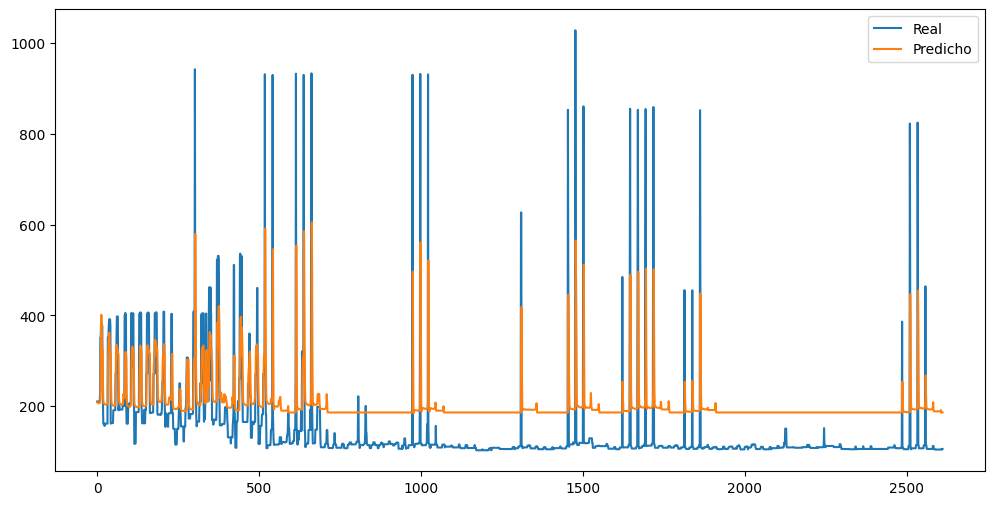

In [52]:
# ============================
# 7. Graphic
# ============================

plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label="Real")
plt.plot(y_pred_inv, label="Predicho")
plt.legend()
plt.show()